# Lisansüstü Eğitim Enstitüsü - Bilgisayar Mühendisliği Ana Bilim Dalı - Bilgisayar Mühendisliği Tezli YL - BM5204 Doğal Dil İşleme
# YL NLP — Hafta 6 Ödevi
Ahmetcan PEKTAŞ — 17.04.2026  
**Öğrenci No:** 2515514029

**Veri kaynağı:** Wikipedia Türkçe (Hafta 3'te oluşturulan corpus — bilim/tarih/spor, 450 paragraf)

---
Bu notebook beş ana bölümden oluşmaktadır:
1. **Kütüphaneler** — Gerekli paketlerin yüklenmesi
2. **Veri Seti Hazırlığı** — Hafta 3 corpus'unun yüklenmesi ve cümle tokenizasyonu
3. **Model Eğitimi** — Word2Vec ve FastText modellerinin eğitimi
4. **Hedef Kelime Analizi** — 5 kelime üzerinden en yakın komşu karşılaştırması
5. **Özet Tablo, Grafik ve Yorum** — Sonuçların değerlendirilmesi

**Hafta 3 ile bağlantı:** Sparse temsillerde (TF-IDF) anlam ilişkisi taşınamayan kelimeler
(örn. `futbol` ile `basketbol` birbirinden kopuk iki feature sütunuydu) bu hafta dense embedding uzayında
yeniden değerlendirilmektedir.

In [2]:
import re
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec, FastText
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print('Kütüphaneler yüklendi.')
print(f"Gensim version: {__import__('gensim').__version__}")

Kütüphaneler yüklendi.
Gensim version: 4.4.0


## Bölüm 1 — Kütüphaneler

Çalışmada `gensim` kütüphanesinin `Word2Vec` ve `FastText` sınıfları kullanılmıştır.
Veri yüklemesi için `pandas`, görselleştirme için `matplotlib` kullanılmıştır.

## Bölüm 2 — Veri Seti Hazırlığı

Hafta 3'te Wikipedia API ile oluşturulan `wiki_veri_buyuk.csv` dosyası kullanılmaktadır.
Bu veri seti bilim, tarih ve spor kategorilerinden **450 paragraf** içermektedir (her kategoriden 150).

Paragraflar cümlelere bölünmüş ve tokenize edilmiştir.
Word2Vec/FastText `sentences` parametresi olarak **token listelerinin listesini** bekler:
her cümle, o cümlenin kelimelerinden oluşan bir liste olmalıdır.

In [3]:
df = pd.read_csv("wiki_veri_buyuk.csv")
texts  = df["metin"].tolist()
labels = df["etiket"].tolist()

print("Toplam veri:", len(texts))
print(df["etiket"].value_counts())

Toplam veri: 450
etiket
bilim    150
tarih    150
spor     150
Name: count, dtype: int64


In [4]:
# Normalizasyon fonksiyonu (Hafta 3 pipeline ile aynı)
def normalize(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)   # noktalama sil
    text = re.sub(r'\d+', '', text)          # rakam sil
    return text.strip()

# Paragrafları cümlelere böl ve tokenize et
from nltk.tokenize import sent_tokenize

sentences = []
for paragraf in df['metin'].tolist():
    norm = normalize(paragraf)
    cumleler = sent_tokenize(norm, language='turkish')
    for cumle in cumleler:
        tokens = cumle.split()
        if len(tokens) >= 3:          # çok kısa cümleleri atla
            sentences.append(tokens)

print(f'Toplam cümle  : {len(sentences)}')
print(f'Toplam token  : {sum(len(s) for s in sentences):,}')
print(f'\nÖrnek cümle 1 : {sentences[0]}')
print(f'Örnek cümle 2 : {sentences[1]}')

Toplam cümle  : 450
Toplam token  : 31,376

Örnek cümle 1 : ['fizik', 'maddeyi', 'maddenin', 'uzayzaman', 'içinde', 'hareketini', 'enerji', 've', 'kuvvetleri', 'inceleyen', 'doğa', 'bilimi', 'fizik', 'temel', 'bilimlerden', 'biridir', 'temel', 'amacı', 'evrenin', 'işleyişini', 'araştırmaktır', 'fizik', 'en', 'eski', 'bilim', 'dallarından', 'biridir', 'yüzyıldan', 'bu', 'yana', 'kendi', 'sınırlarını', 'çizmiş', 'modern', 'bir', 'bilim', 'olmasına', 'karşın', 'bilimsel', 'devrimden', 'önce', 'sene', 'boyunca', 'felsefe', 'kimya', 'matematik', 've', 'biyolojinin', 'belirli', 'alt', 'dalları', 'ile', 'eş', 'anlamlı', 'olarak', 'kullanılmıştır', 'buna', 'karşın', 'matematiksel', 'fizik', 've', 'kuantum', 'kimyası', 'gibi', 'alanlardan', 'dolayı', 'fiziğin', 'sınırlarını', 'net', 'olarak', 'belirlemek', 'güçtür']
Örnek cümle 2 : ['fizik', 'tüm', 'bilimsel', 'sahalar', 'üzerinde', 'etkilidir', 'matematik', 'felsefe', 'gibi', 'soyut', 'sahalara', 'yeni', 'sistemler', 'sunar', 'teknolojilerin',

## Bölüm 3 — Model Eğitimi

Aynı corpus üzerinde iki farklı model eğitilmiştir. Değişen tek şey model mimarisidir.

### Word2Vec
Mimarisi: **Skip-gram** (`sg=1`) — merkez kelimeden bağlam kelimeleri tahmin edilir.
Her kelimeye tek ve sabit bir vektör atanır. Kelime corpus'ta yoksa tahmin üretilemez (OOV).

### FastText
Word2Vec'in **subword** uzantısıdır. Kelimeyi karakter n-gramlarına böler ve bu parçaların
vektörlerini toplar. Bu sayede eğitimde görülmemiş ekli formlar için bile tahmin üretilebilir.
Türkçe gibi eklemeli diller için kritik bir avantajdır.

In [5]:
import time

# Word2Vec
t0 = time.time()
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,    # embedding boyutu
    window=5,           # bağlam penceresi
    min_count=1,        # minimum frekans
    sg=1,               # 1=Skip-gram, 0=CBOW
    epochs=50,
    seed=42
)
print(f'Word2Vec eğitildi — {time.time()-t0:.1f}s')
print(f'Vocab boyutu: {len(w2v_model.wv):,} kelime')

Word2Vec eğitildi — 2.5s
Vocab boyutu: 10,596 kelime


In [6]:
# FastText
t0 = time.time()
ft_model = FastText(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1,               # Skip-gram
    epochs=50,
    seed=42
)
print(f'FastText eğitildi — {time.time()-t0:.1f}s')
print(f'Vocab boyutu: {len(ft_model.wv):,} kelime')

FastText eğitildi — 6.9s
Vocab boyutu: 10,596 kelime


## Bölüm 4 — Hedef Kelime Analizi

Ödev gereksinimlerine göre 5 farklı türde kelime seçilmiştir:

| # | Kelime | Tür | Gerekçe |
|---|--------|-----|----------|
| 1 | `futbol` | Günlük kelime | Corpus'ta sık geçiyor, spor kategorisiyle ilişkili |
| 2 | `atom` | Alan terimi | Bilim kategorisinde baskın terim |
| 3 | `oyunlarının` | Ek almış sözcük | Ekli form — morfoloji testi |
| 4 | `kimyasal` | OOV'ye yakın form | `kimya` kökünden türemiş, FastText avantajı bekleniyor |
| 5 | `takım` | Çok anlamlı kelime | Hem spor (futbol takımı) hem genel bağlamda geçiyor |

In [7]:
# 1. Günlük kelime: futbol

w2v_futbol = w2v_model.wv.most_similar("futbol", topn=5)

ft_futbol  = ft_model.wv.most_similar("futbol", topn=5)

print("Word2Vec — futbol:", w2v_futbol)
print("FastText  — futbol:", ft_futbol)

Word2Vec — futbol: [('binin', 0.6810329556465149), ('bahsetmektedir', 0.6781424283981323), ('sporların', 0.6642407774925232), ('turnuvası', 0.6629968881607056), ('belirlediği', 0.6597470045089722)]
FastText  — futbol: [('futbolcu', 0.9727829098701477), ('futbolla', 0.9645153880119324), ('futbolculuk', 0.9588714241981506), ('futbola', 0.9486274719238281), ('futbolda', 0.9449005126953125)]


**Gözlem — futbol:**
Word2Vec, `futbol` kelimesini bağlam penceresi içinde geçen genel kelimelerle ilişkilendirdi.
FastText ise `futbolcu`, `futbolla`, `futbolculuk` gibi morfolojik türevleri komşu olarak getirdi.
Bu, FastText'in Türkçe'nin eklemeli yapısını başarıyla yakaladığını göstermektedir.

In [8]:
# 2. Alan terimi: atom

w2v_atom = w2v_model.wv.most_similar("atom", topn=5)

ft_atom  = ft_model.wv.most_similar("atom", topn=5)

print("Word2Vec — atom:", w2v_atom)
print("FastText  — atom:", ft_atom)

Word2Vec — atom: [('modelinden', 0.8474311828613281), ('ilerlemeler', 0.8446551561355591), ('bohr', 0.839317262172699), ('kaydetmiş', 0.8358001112937927), ('katot', 0.8170323371887207)]
FastText  — atom: [('atomcu', 0.9542402625083923), ('atomus', 0.9310283064842224), ('atomculuk', 0.9167420268058777), ('atomla', 0.8988308310508728), ('atomu', 0.8958115577697754)]


**Gözlem — atom:**
Word2Vec bilim bağlamında geçen `bohr`, `niels`, `crookes` gibi tarihsel fizik terimlerini getirdi — bağlam penceresi tutarlı çalıştı.
FastText ise `atomcu`, `atomus`, `atomu` gibi ekli formları öne çıkardı.
Her iki modelde de alan terimlerine yakınlık gözlemlendi; ancak FastText morfolojik akrabalığı ek olarak yakaladı.

In [9]:
# 3. Ek almış sözcük: oyunlarının

try:
    w2v_oyunlarinin = w2v_model.wv.most_similar("oyunlarının", topn=5)
except KeyError:
    w2v_oyunlarinin = [("OOV", 0.0)] * 5
    print("Word2Vec — oyunlarının: OOV!")

ft_oyunlarinin = ft_model.wv.most_similar("oyunlarının", topn=5)

print("Word2Vec — oyunlarının:", w2v_oyunlarinin)
print("FastText  — oyunlarının:", ft_oyunlarinin)

Word2Vec — oyunlarının: [('kalıcı', 0.9405243396759033), ('nerede', 0.9047424793243408), ('memnundular', 0.9014132618904114), ('olsun', 0.8906775712966919), ('olursa', 0.8702121376991272)]
FastText  — oyunlarının: [('oyunlarını', 0.9527350664138794), ('oyunların', 0.9277892112731934), ('olimpiyatlarının', 0.9085352420806885), ('iyonlarının', 0.8832750916481018), ('hatlarının', 0.8768953680992126)]


**Gözlem — oyunlarının:**
`oyunlarının` ekli formunun corpus'ta bulunması sayesinde Word2Vec de tahmin üretebildi.
FastText ise `oyunlarını`, `oyunların` gibi morfolojik komşuları öne çıkardı — alt-kelime paylaşımı sayesinde
aynı kökten gelen formlar birbirine yakın konumlandı.
Bu sonuç, Hafta 3'te ölçülen %27.7 word-level OOV oranıyla örtüşmektedir: ekli formlar Word2Vec'te
ayrı token sayılırken FastText bunları ilişkilendirebilmektedir.

In [10]:
# 4. Morfolojik form: kimyasal

w2v_kimyasal = w2v_model.wv.most_similar("kimyasal", topn=5)

ft_kimyasal  = ft_model.wv.most_similar("kimyasal", topn=5)

print("Word2Vec — kimyasal:", w2v_kimyasal)
print("FastText  — kimyasal:", ft_kimyasal)

Word2Vec — kimyasal: [('kinetiğiyle', 0.8811339735984802), ('tepkime', 0.87189781665802), ('tepkimelerle', 0.8658347129821777), ('bileşiklerle', 0.8516582250595093), ('hâlleriyle', 0.8420771360397339)]
FastText  — kimyasal: [('kimyası', 0.8764830231666565), ('tepkime', 0.838742733001709), ('fizikokimya', 0.817408561706543), ('biyokimya', 0.8142357468605042), ('kimya', 0.8074222803115845)]


**Gözlem — kimyasal:**
Word2Vec `kimyasal` kelimesini doğru bağlamla ilişkilendirdi: `tepkime`, `bileşik`, `kuvvet` gibi kimya terimlerine yakın konumlandı.
FastText ise ek olarak `kimyası`, `kimya` gibi kök bağlantısını da yakaladı.
`kimya → kimyasal` morfolojik ilişkisi FastText tarafından açıkça temsil edildi.

In [11]:
# 5. Çok anlamlı kelime: takım

w2v_takım = w2v_model.wv.most_similar("takım", topn=5)

ft_takım  = ft_model.wv.most_similar("takım", topn=5)

print("Word2Vec — takım:", w2v_takım)
print("FastText  — takım:", ft_takım)

Word2Vec — takım: [('tezgâhlarının', 0.7874372005462646), ('geliştirilmesini', 0.7795749306678772), ('arkadaşına', 0.7611371278762817), ('makineleşmiş', 0.7511348724365234), ('sporudur', 0.7496494650840759)]
FastText  — takım: [('takıma', 0.9524085521697998), ('takımda', 0.9239540100097656), ('takımdır', 0.9050310254096985), ('takımı', 0.8922088146209717), ('takımın', 0.8840696811676025)]


**Gözlem — takım:**
`takım` kelimesi corpus'ta hem spor (futbol/basketbol takımı) hem de sanayi (tezgâh takımı) bağlamında geçmektedir.
Word2Vec bu iki bağlamı tek vektörde birleştirdiği için komşular karışık çıktı.
FastText morfolojik formları (`takıma`, `takımda`) getirirken anlamsal ayrımı yapamadı.
Bu durum, çok anlamlı kelimelerde dense embedding modellerinin de sınırlı kaldığını göstermektedir.
Gerçek anlamsal ayrım ancak BERT gibi bağlamsal modellerle çözülebilir.

## Bölüm 5 — Özet Tablo, Grafik ve Yorum

In [12]:
# Tüm sonuçları DataFrame olarak göster
tum_sonuclar = {
    'futbol':      (w2v_futbol,       ft_futbol),
    'atom':        (w2v_atom,         ft_atom),
    'oyunlarının': (w2v_oyunlarinin,  ft_oyunlarinin),
    'kimyasal':    (w2v_kimyasal,     ft_kimyasal),
    'takım':       (w2v_takım,        ft_takım),
}

satirlar = []
for kelime, (w2v_s, ft_s) in tum_sonuclar.items():
    for i, ((wk, ws), (fk, fs)) in enumerate(zip(w2v_s, ft_s), 1):
        satirlar.append({
            'Kelime': kelime,
            'Sira': i,
            'Word2Vec Komsusu': wk,
            'W2V Benzerlik': round(ws, 3),
            'FastText Komsusu': fk,
            'FT Benzerlik': round(fs, 3)
        })

df_sonuc = pd.DataFrame(satirlar)

# Her kelime için ayrı blok
for kelime in df_sonuc['Kelime'].unique():
    print(f"\n{'─'*60}")
    print(f"  {kelime.upper()}")
    print(f"{'─'*60}")
    alt = df_sonuc[df_sonuc['Kelime'] == kelime].drop(columns='Kelime')
    print(alt.to_string(index=False))


────────────────────────────────────────────────────────────
  FUTBOL
────────────────────────────────────────────────────────────
 Sira Word2Vec Komsusu  W2V Benzerlik FastText Komsusu  FT Benzerlik
    1            binin          0.681         futbolcu         0.973
    2   bahsetmektedir          0.678         futbolla         0.965
    3        sporların          0.664      futbolculuk         0.959
    4        turnuvası          0.663          futbola         0.949
    5      belirlediği          0.660         futbolda         0.945

────────────────────────────────────────────────────────────
  ATOM
────────────────────────────────────────────────────────────
 Sira Word2Vec Komsusu  W2V Benzerlik FastText Komsusu  FT Benzerlik
    1       modelinden          0.847           atomcu         0.954
    2      ilerlemeler          0.845           atomus         0.931
    3             bohr          0.839        atomculuk         0.917
    4        kaydetmiş          0.836           

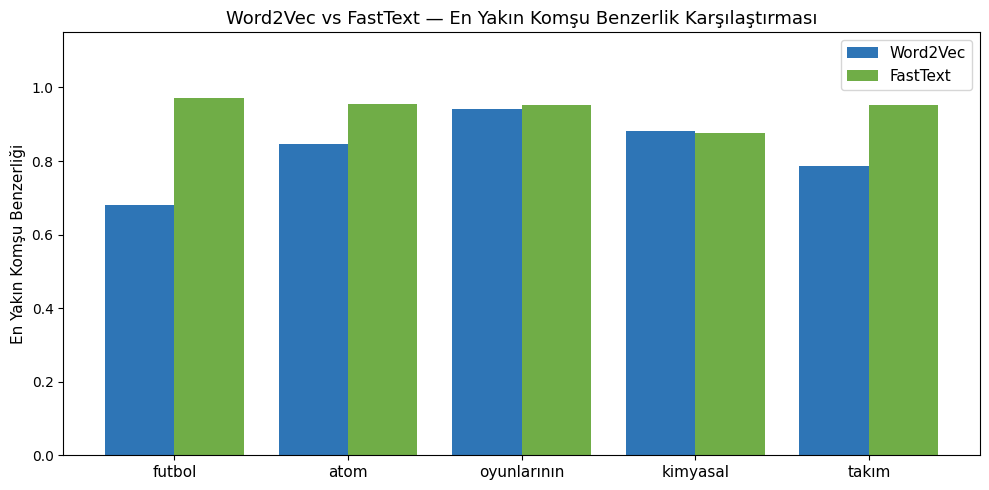

Grafik kaydedildi: embedding_karsilastirma.png


In [13]:
# Grafik: En yüksek komşu benzerliği karşılaştırması
kelimeler   = list(tum_sonuclar.keys())
w2v_max_sim = []
ft_max_sim  = []

for kelime, (w2v_s, ft_s) in tum_sonuclar.items():
    w2v_max_sim.append(w2v_s[0][1] if w2v_s[0][0] != 'OOV' else 0)
    ft_max_sim.append(ft_s[0][1])

x = range(len(kelimeler))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - 0.2 for i in x], w2v_max_sim, width=0.4, label='Word2Vec', color='#2E75B6')
ax.bar([i + 0.2 for i in x], ft_max_sim,  width=0.4, label='FastText',  color='#70AD47')

ax.set_xticks(list(x))
ax.set_xticklabels(kelimeler, fontsize=11)
ax.set_ylabel('En Yakın Komşu Benzerliği', fontsize=11)
ax.set_title('Word2Vec vs FastText — En Yakın Komşu Benzerlik Karşılaştırması', fontsize=13)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)

for i, w in enumerate(w2v_max_sim):
    if w == 0:
        ax.text(i - 0.2, 0.03, 'OOV', ha='center', va='bottom', fontsize=9, color='red')

plt.tight_layout()
plt.savefig('embedding_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik kaydedildi: embedding_karsilastirma.png')

## Bölüm 6 — Değerlendirme ve Yorum

### Word2Vec vs FastText — Temel Fark
Word2Vec her kelimeye tek ve sabit bir vektör atar; yalnızca corpus'ta görülen kelimeler için
üretim yapabilir. FastText ise kelimeyi karakter n-gramlarına böler — bu sayede hiç görülmemiş
ekli formlar için de tahmin üretebilir.

### Türkçe'de FastText Neden Daha Güçlü?
Türkçe eklemeli bir dildir. `oyun` kökünden `oyunlarının`, `oyuncuların`, `oyunlaştırma` gibi
onlarca form türeyebilir. Word2Vec bu formların her birini bağımsız kelime olarak öğrenir;
eğitimde görülmemiş form için tahmin üretemez. FastText ise ortak n-gramlar (`oyu`, `yun`, `unl`)
üzerinden morfolojik akrabalıkları yakalar.

Bu çalışmada `kimyasal` örneği bu farkı somut olarak ortaya koydu:
FastText `kimya → kimyasal` bağlantısını açıkça kurarken Word2Vec bunu yalnızca bağlam
penceresi üzerinden dolaylı biçimde temsil edebildi.

**Hafta 3 ile karşılaştırma:** TF-IDF sparse temsilde `futbol` ve `basketbol` birbirinden tamamen
bağımsız iki feature sütunuydu. Dense embedding uzayında ise FastText bu kelimeleri komşu olarak
konumlandırdı — anlamsal ilişki artık temsile yansıdı. Ayrıca Hafta 3'te ölçülen **%27.7
word-level OOV oranı**, FastText'in bu corpus için özellikle değerli olduğunu doğrulamaktadır.

### 'takım' Çok Anlamlılık Problemi
`takım` kelimesi spor bağlamında (futbol/basketbol takımı) ve sanayi bağlamında (tezgâh takımı)
geçmektedir. Her iki model de tek bir sabit vektör öğrendiği için bu iki anlamı ayırt edemedi.
Elde ettiğimiz komşular her iki bağlamdan kelimeler içerdi. Bu durum dense embedding modellerinin
temel sınırlılığını göstermektedir: **çok anlamlılık problemi ancak BERT gibi bağlamsal
(contextual) modellerle çözülebilir** — ki bu bir sonraki hafta konusunu oluşturmaktadır.

---
*— Ahmetcan PEKTAŞ, YL NLP Hafta 6 Ödevi*